In [8]:
from ultralytics import YOLO 
import torch
import contextlib
import io
import yolo_patch
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)


0: 480x640 9 persons, 1 sports ball, 64.2ms
Speed: 2.1ms preprocess, 64.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Bounding boxes (xyxy): [[     65.184      52.652         274       402.3]
 [     182.96      34.821      227.97      81.386]
 [    0.28319      220.03      76.783      372.32]
 [     301.76      203.45      370.87      361.79]
 [     204.76      244.08      246.32      357.19]
 [     292.42       298.6      317.28      349.72]
 [     255.84      317.35      261.58      334.33]
 [     351.45      316.53      365.45      338.57]
 [     420.24      316.19      428.65      329.68]
 [     431.24      315.58       438.7      328.81]]
Confidence scores: [[    0.95056]
 [    0.93222]
 [    0.92497]
 [    0.90752]
 [     0.8679]
 [    0.78571]
 [    0.44299]
 [    0.42546]
 [    0.37208]
 [    0.25192]]
Class indices: [ 0 32  0  0  0  0  0  0  0  0]
Class names: ['person', 'sports ball', 'person', 'person', 'person', 'person', 'person', 'person', 'person'

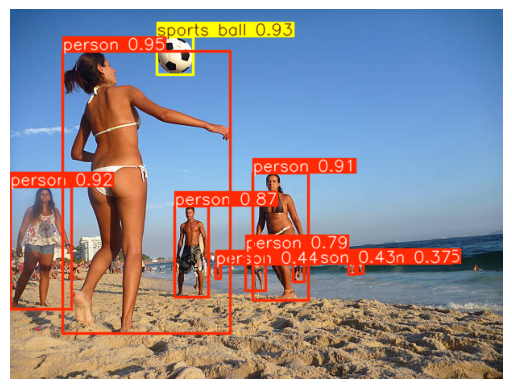

In [9]:
# Load image from current directory
image_path = "image.jpg"  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
results = yolo_model(image, device=device, conf=0.25, iou=0.45, agnostic_nms=True, max_det=1000)

result = results[0]  # One image, one result
xyxy = result.boxes.xyxy.cpu().numpy()  # (N, 4)
conf = result.boxes.conf.cpu().numpy()  # (N,)
cls = result.boxes.cls.cpu().numpy()    # (N,)
prob_vectors = result.boxes.data[:, 6:].cpu().numpy() # Probability vectors for each class
names = result.names  # Class names

print("Bounding boxes (xyxy):", xyxy)
print("Confidence scores:", conf)
print("Class indices:", cls)
print("Class names:", [names[int(c)] for c in cls])
print("Probability vectors:", prob_vectors)

# Convert results to an image with bounding boxes
img_with_boxes = results[0].plot()

# Display the image
plt.imshow(img_with_boxes)
plt.axis("off")  # Hide axes for better visualization
plt.show()